**My hypothesis is that adjusting the baseline model can allow it to generalize to unseen data**

In [11]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import json
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
paths_path = r"info\paths.json"
with open(paths_path, 'r') as f:
    paths = json.load(f)

model_path = paths["split vector std dev 1e-8"]

In [15]:
metrics_path = model_path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

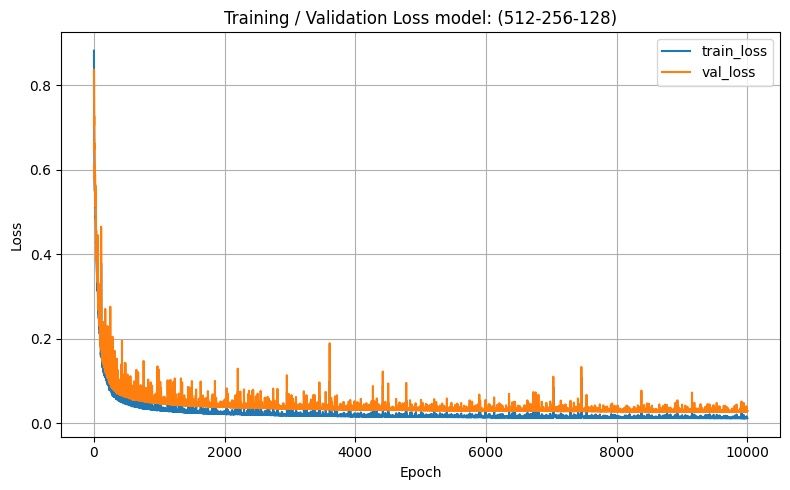

In [16]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training / Validation Loss model: (512-256-128)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(model_path, '*.pth')) + glob.glob(os.path.join(model_path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(model_path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {model_path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)

In [18]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=26, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [19]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')
if 'env_delta_t' in env_config:
    env_config['delta_t'] = env_config.pop('env_delta_t')

env = CoronagraphEnvironment(**env_config)

initializing coronagraph env. might take a minute.


Using split vector: True
Using slopes: False


  0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\alexe\AppData\Local\Temp\ipykernel_22556\2020595961.py:65: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  prediction_magnitudes.append(np.abs(pred_mag))
C:\Users\alexe\AppData\Local\Temp\ipykernel_22556\2020595961.py:82: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred)
  0%|          | 2/1000 [00:00<01:00, 16.40it/s]C:\Users\alexe\AppData\Local\Temp\ipykernel_22556\2020595961.py:65: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  prediction_magni

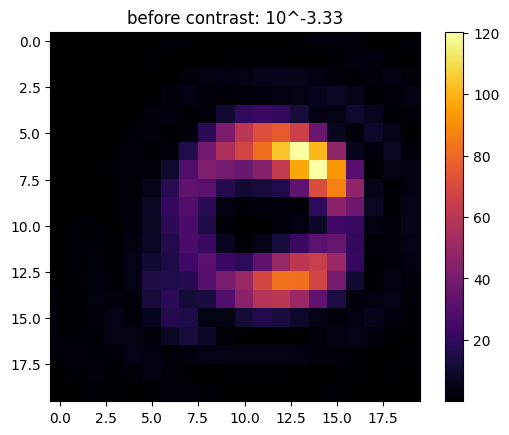

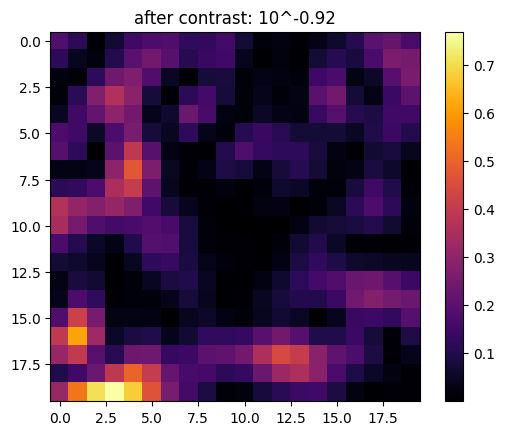

In [35]:
from train_job import NORMALIZERS
import tqdm

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

train_type = metrics_data['args'].get('train_type', 'images')
slopes_train = (train_type == "slopes")

split_vector = metrics_data['args'].get('split_vector', False)

print(f"Using split vector: {split_vector}")
print(f"Using slopes: {slopes_train}")

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

similarities = []

noise_levels = np.linspace(1e-9, 3e-7, 1000)

# noise_levels = [2e-7] # [1e-8, 5e-8, 1e-7, 2e-7, 3e-7, 4e-7]

contrasts = []
predictions = []
truths = []

for noise in tqdm.tqdm(noise_levels):
    prediction_magnitudes = []
    contrast_differences = []
    for _ in range(N):
            env.deformable_mirror.flatten()
            # env.noise_gen_mirror.flatten()
            env.set_random_dm(noise=noise)
            # env.set_nudge_vectors(vectors=[nudge_vec])
            original = env.deformable_mirror.actuators.copy()

            original_contrast = env.get_contrast(delta_t=1e15)
            contrasts.append(original_contrast)

            imgs = env.generate_diversity_images(delta_t=1e-1, noise_enabled=False)

            slopes = env.get_slopes()
            
            with torch.no_grad():
                if slopes_train:
                    slopes = torch.asarray(slopes, dtype=torch.float).unsqueeze(0).unsqueeze(-1)
                    imgs_norm, _ = x_norm_func(slopes, **params)
                else:
                    imgs = torch.asarray(imgs).unsqueeze(0)
                    imgs_norm, _ = x_norm_func(imgs, **params)
                
                imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
                y_pred = model(imgs_norm)

                y_pred = y_pred.squeeze(0)                     

                pred_mag = np.linalg.norm(y_pred) if not split_vector else y_pred[-1]
                prediction_magnitudes.append(np.abs(pred_mag))

                predictions.append(y_pred.cpu().numpy())
                truths.append(original)

                if split_vector:
                     y_pred = y_pred[:-1]
                y_pred *= y_std
                y_pred -= y_mean


            orig_t = torch.as_tensor(original, dtype=y_pred.dtype, device=y_pred.device).unsqueeze(0)
            cos_sim = torch.nn.functional.cosine_similarity(y_pred, orig_t, dim=1).item()
            similarities.append(cos_sim)
            # print(f"cosine_similarity: {cos_sim:.6f}")

            env.deformable_mirror.flatten()
            env.deformable_mirror.actuators = original - np.array(y_pred)
            new_contrast = env.get_contrast(delta_t=1e15)
            contrast_differences.append((original_contrast - new_contrast) / original_contrast)


    # print(f"Noise level: {noise}")
    # print(f"  avg prediction magnitude: {np.mean(prediction_magnitudes)}")
    # print(f"  avg contrast improvement: {np.mean(contrast_differences)}")
    # print(f"  avg cosine similarity: {np.mean(similarities)}")

# print(f"avg prediction magnitude: {np.mean(prediction_magnitudes)}")
# print(f"avg contrast improvement: {np.mean(contrast_differences)}")
# print(f"avg cosine similarity: {np.mean(similarities)}")

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(imgs[0][0] if not slopes_train else imgs[0], cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()

In [36]:
contrasts, similarities, predictions, truths = np.array(contrasts), np.array(similarities), np.array(predictions), np.array(truths)

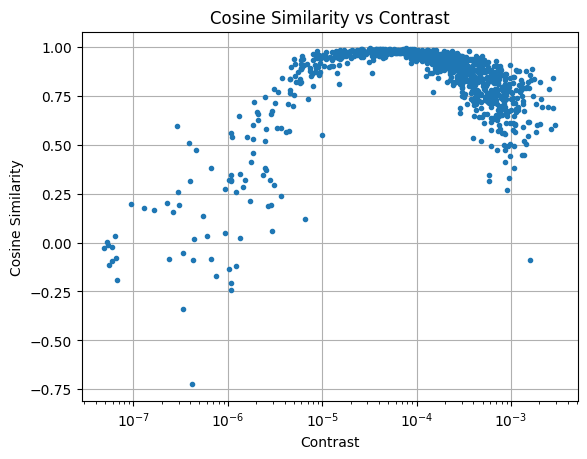

In [44]:
N=1
similarities_array = np.array(similarities).reshape(len(contrasts), N)
similarities_mean = np.mean(similarities_array, axis=1)

plt.plot(contrasts, similarities_mean, '.', label='cosine similarity')
plt.xlabel('Contrast')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Contrast')
plt.xscale('log')
plt.grid()
plt.show()

$$\text{argmin}_{\alpha} (\vert \vert X - \alpha y \vert \vert)$$

$$= \text{argmin}_{\alpha} (\sum_{i=1}^{p} (\alpha x_i - y_i)^2)$$

$$ \text{Take partial w.r.t } \alpha$$

$$ \frac{\partial}{\partial \alpha} (\sum_{i=1}^{p} (\alpha x_i - y_i)^2) = \sum_{i=1}^{p} 2(\alpha x_i - y_i)(x_i)$$

$$ \text{Set this equal to 0} $$

$$ \sum_{i=1}^{p} 2(\alpha x_i - y_i)(x_i) = 0 $$

$$ \sum_{i=1}^{p} (\alpha x_i^2 - y_i x_i) = 0 $$

$$ \sum_{i=1}^{p} \alpha x_i^2 - \sum_{i=1}^{p} y_i x_i = 0 $$

$$ \sum_{i=1}^{p} \alpha x_i^2 = \sum_{i=1}^{p} y_i x_i $$

$$ \alpha \sum_{i=1}^{p} x_i^2 = \sum_{i=1}^{p} y_i x_i $$

$$ \alpha = \frac{\sum_{i=1}^{p} y_i x_i}{\sum_{i=1}^{p} x_i^2} $$

In [39]:
len(contrasts), len(predictions), len(truths)

if split_vector:
    predictions = np.array([pred[:-1] for pred in predictions])

In [45]:
y = truths[0]
pred = predictions[0]

alpha = np.sum(pred * y) / np.sum(pred * pred)

In [46]:
# in implementation:

order = np.argsort(contrasts)

alphas = [  np.sum(pred * y) / np.sum(pred * pred) for pred, y in zip(predictions, truths) ]
alphas = np.array(alphas)[order]
contrasts = np.array(contrasts)[order]
N=10

average_alphas = np.convolve(alphas, np.ones(N)/N, mode='valid')
# rolling average of alphas

In [47]:
average_alphas.shape

(991,)

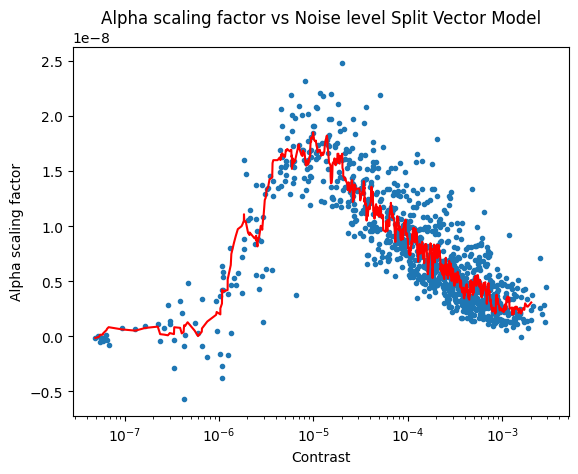

In [48]:
plt.plot(contrasts, alphas, '.')
plt.plot(contrasts[:len(average_alphas)], average_alphas, '-r')
plt.title("Alpha scaling factor vs Noise level Split Vector Model")
plt.xlabel("Contrast")
plt.xscale("log")
plt.ylabel("Alpha scaling factor")
plt.show()


In [49]:
def get_alpha_for_contrast(contrast, k=20):
    # Use K-nearest neighbors
    idx = np.argsort(np.abs(contrasts - contrast))[:k]
    return np.mean(alphas[idx])

In [51]:
get_alpha_for_contrast(1e-5)

np.float64(1.6855695833569148e-08)

prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.267117
actual scale: 2.2363281250000004e-08
cosine_similarity: 0.016045
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.267117
actual scale: 2.220882910061393e-08
cosine_similarity: 0.014844


C:\Users\alexe\AppData\Local\Temp\ipykernel_22556\2085511796.py:81: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"prediction magnitude after scaling: 10^{np.log10(pred_mag):.6f}")


prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.267117
actual scale: 2.2066516891078743e-08
cosine_similarity: 0.013617
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.267117
actual scale: 2.1936585136697036e-08
cosine_similarity: 0.012368
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.267117
actual scale: 2.1936585136697036e-08
cosine_similarity: 0.012368
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.220548
actual scale: 2.181925439843272e-08
cosine_similarity: 0.012352
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.220548
actual scale: 2.181925439843272e-08
cosine_similarity: 0.012352
prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.220548
actual scale: 2.170372496826301e-08
cosine_similarity: 0.010754
prediction magnitude before scaling: 1.0000

KeyboardInterrupt: 

prediction magnitude before scaling: 1.000000
prediction magnitude after scaling: 10^-9.220548
actual scale: 2.1454734876769396e-08
cosine_similarity: 0.005810


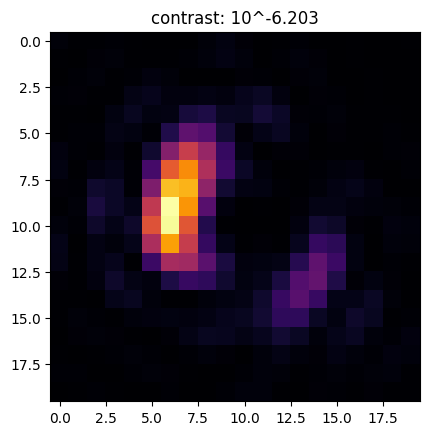

In [60]:
import matplotlib.animation as animation

delta_t = 1e-1

fig, ax = plt.subplots()

def init(noise=1e-7):
    env.noise_gen_mirror.flatten()
    env.deformable_mirror.flatten()
    env.set_random_dm(noise=noise)
    env.deformable_mirror.actuators = np.array(env.deformable_mirror.actuators)

    contrast = np.log10(env.get_contrast(delta_t=1e15))
    img = env.get_camera_image(delta_t=delta_t, noise_enabled=False)

    ax.imshow(img, cmap='inferno')
    ax.set_title(f"contrast: 10^{contrast}")

init(noise=1e-8)

# Store previous prediction as a torch tensor for consistent math
previous_prediction = torch.zeros((env.num_modes,), dtype=torch.float32)


def safe_alpha(original_contrast, k=20):
    """Wrapper for get_alpha_for_contrast that clips to a reasonable range."""
    a = get_alpha_for_contrast(original_contrast, k=k)
    if np.isnan(a) or np.isinf(a):
        return 1.0
    return a


def orthogonalize(current: torch.Tensor, prev: torch.Tensor) -> torch.Tensor:
    """Project `current` off the direction of `prev` (Torch only, avoids NumPy deprecation warnings)."""
    prev_norm_sq = torch.dot(prev, prev)
    if prev_norm_sq.item() < 1e-20:
        return current  # nothing to remove
    dot_prod = torch.dot(current, prev)
    return current - (dot_prod / prev_norm_sq) * prev


def update(frame):
    global previous_prediction
    original = env.deformable_mirror.actuators.copy()
    original_contrast = env.get_contrast(delta_t=1e15)
    imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
    slopes = env.get_slopes()

    with torch.no_grad():
        if slopes_train:
            slopes_t = torch.as_tensor(slopes, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            imgs_norm_np, _ = x_norm_func(slopes_t.numpy(), **params)  # normalizer expects numpy
        else:
            imgs_t = torch.as_tensor(imgs, dtype=torch.float32).unsqueeze(0)
            imgs_norm_np, _ = x_norm_func(imgs_t.numpy(), **params)

        # Convert back to torch (FC1 expects (N,H,W,C))
        imgs_norm_np = np.transpose(imgs_norm_np, (0, 2, 3, 1))
        y_pred = model(torch.as_tensor(imgs_norm_np, dtype=torch.float32))  # (1, D)
        y_pred = y_pred.squeeze(0)  # (D,)

        if split_vector:
            vec_part = y_pred[:-1]
            magnitude_part = y_pred[-1]
            work_pred = vec_part
            work_pred /= np.linalg.norm(vec_part)
        else:
            work_pred = y_pred

        # Un-normalize (matches train_job procedure)
        work_pred = work_pred * y_std - y_mean

        print(f"prediction magnitude before scaling: {torch.linalg.vector_norm(work_pred).item():.6f}")

        # Alpha scaling (clip to prevent blow-up)
        alpha = safe_alpha(original_contrast, k=20)
        work_pred = work_pred * alpha

        pred_mag = torch.linalg.vector_norm(work_pred)

        print(f"prediction magnitude after scaling: 10^{np.log10(pred_mag):.6f}")

        print(f"actual scale: {np.linalg.norm(np.array(original))}")

        # Orthogonalize against previous prediction (Torch-safe)
        # work_pred = orthogonalize(work_pred, previous_prediction)

        # work_pred = work_pred / torch.linalg.vector_norm(work_pred) * pred_mag
        
        # Update previous prediction (detach to avoid grad accumulation)
        previous_prediction = work_pred.detach().clone()

    # Apply correction (convert to numpy)
    correction = work_pred.detach().cpu().numpy().astype(float)
    env.deformable_mirror.flatten()
    env.deformable_mirror.actuators = original - correction
    new_contrast_log10 = np.log10(env.get_contrast(delta_t=1e15) + 1e-30)

    orig_t = torch.as_tensor(original, dtype=y_pred.dtype, device=y_pred.device).unsqueeze(0)
    cos_sim = torch.nn.functional.cosine_similarity(work_pred, orig_t, dim=1).item()

    print(f"cosine_similarity: {cos_sim:.6f}")

    img = env.get_camera_image(delta_t=delta_t, noise_enabled=False)
    ax.imshow(img, cmap='inferno')
    ax.set_title(f"contrast: 10^{new_contrast_log10:.3f}")

ani = animation.FuncAnimation(fig=fig, func=update, frames=25, interval=250)
ani.save('footage/SplitVectorVideo.mp4', writer='ffmpeg', dpi=200)

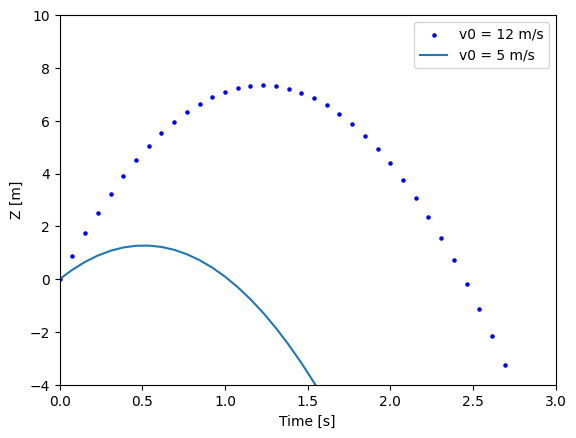

In [102]:
fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)
g = -9.81
v0 = 12
z = g * t**2 / 2 + v0 * t

v02 = 5
z2 = g * t**2 / 2 + v02 * t

scat = ax.scatter(t[0], z[0], c="b", s=5, label=f'v0 = {v0} m/s')
line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=[0, 3], ylim=[-4, 10], xlabel='Time [s]', ylabel='Z [m]')
ax.legend()

def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
ani.save('footage/scatter_line_animation.mp4', writer='ffmpeg', dpi=200)
plt.show()